In [ ]:
import pandas as pd
import numpy as np
import os
from functools import reduce
from scipy import stats
import cvxpy as cp
from datetime import datetime
from collections import defaultdict
import pickle

srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base"
adir = "E:/SJTU/实习/国泰海通/barra因子/result"
spedir = "E:/SJTU/实习/国泰海通/barra因子/result"

def orthogonalize_pair(df, col1, col2):
    x1 = df[col1].values
    x2 = df[col2].values
    
    beta = np.dot(x1, x2) / np.dot(x1, x1)
    x2_new = x2 - beta * x1
    
    df[col2] = x2_new
    return df

files = sorted(os.listdir(f"{srcdir}/base_data/whole_mkt")) #2025-01-01 ~ 2026-03-25
mcp_dict = pd.read_pickle(f"{srcdir}/stk_mcp/全A_freemcp_25_26D_dict.pkl")
return_dict = pd.read_pickle(f"{srcdir}/stk_ret/全A_ret_24_2603D_dict.pkl")
alpha_dict = pd.read_pickle(f"{adir}/延迟alpha/delay_measures_2024_2026_dict.pkl")
alpha_name = "D1"#"DELAY"#'MACD_HIST'
#lam = 1
slope, intercept = 0.0674, 0.0793
num_ori = 100
pair_lst = [['earnings_yield', 'liquidity'],['beta', 'residual_volatility'],['non_linear_size', 'size']]
rou_list = [-0.308,0.357,0.510] #根据pair_lst去查数
with open(f"{srcdir}/index_component_日频/000905.XSHG_20_26D_dict.pkl", 'rb') as f:
    weight_dict = pickle.load(f) #series

ret_dict = defaultdict(list)#{}
dual_dict = defaultdict(list) #测试lam取值的时候改！
error_dt = defaultdict(list)
lam_lst = []
reg_lst = []


for i in range(len(files)-1): #1 len(files)+5
    # if w0 is None:

    #明确时间域
    alpha_dt = files[i]#"2025-04-10.pkl"#
    alpha_dt_tp = pd.to_datetime(alpha_dt.split(".pkl")[0])
    base_dt = pd.to_datetime(files[i+1].split(".pkl")[0])#dt + ".pkl"#
    print(f"获取{alpha_dt[:10]}天的因子数据并收盘买入，{base_dt}天卖出")

    #读取数据，最优化
    #df_base = pd.read_pickle(f"{srcdir}/base_data/whole_mkt/{base_dt}")
    df_mcp = mcp_dict[base_dt] #其实用不到，因子协方差是时序数据
    df_ret = return_dict[base_dt].droplevel("date").rename(columns={"value":"ret"})
    df_alpha = alpha_dict[alpha_dt_tp]
    df_barra = pd.read_pickle(f"{srcdir}/barra_data/whole_mkt/{alpha_dt}") #000905标准化2
    X_center = pd.read_pickle(f"{srcdir}/barra_data/000905标准化3_含行业/{alpha_dt}") #
    variance_frq = pd.read_pickle(f"{srcdir}/fac_ret_cov/{alpha_dt}")
    variance_rq = pd.read_pickle(f"{srcdir}/spe_ret_cov/{alpha_dt}")
    weight_index = weight_dict[alpha_dt_tp]

    df_base = df_mcp.merge(df_ret,on="order_book_id")
    #df_base['order_book_id'] = df_base['code'].str.replace('.SZ','.XSHE').str.replace('.SH','.XSHG')

    dfs = [df_alpha,df_barra,df_base]
    df_reg = reduce(lambda left, right:left.merge(right,on="order_book_id"),dfs)    #t天的alpha、因子暴露和t+1天的收益
    weight_bmk = df_reg.merge(weight_index,on="order_book_id",how="left")["weight"]
    weight_bmk = weight_bmk.fillna(0)

    Rhat_series = (intercept + slope * df_reg[alpha_name])
    Rhat = Rhat_series.fillna(Rhat_series.median()).values
    Num = len(df_reg)

    orth_order = [x for x in variance_frq.index.tolist()[:11] if x != "comovement"]#["beta","momentum","size","non_linear_size","residual_volatility","liquidity","book_to_price","earnings_yield","growth","leverage"]
    ind_order = list(variance_frq.columns[11:].values)
    X_original = df_reg[orth_order+ind_order].values #风格+行业
    stk_order = df_reg["order_book_id"].tolist()
    #部分正交化
    flat_pair = [item for sublist in pair_lst for item in sublist]
    non_orth = [var for var in orth_order if var not in flat_pair]
    num_non = len(non_orth) #non_orth + ind_order / non_orth
    X_center =X_center.set_index("order_book_id").loc[stk_order, non_orth + flat_pair] #ind_order + 
    for c1, c2 in pair_lst:
        X_center = orthogonalize_pair(X_center, c1, c2)
    X_center = X_center.values
    # X_center = X_center.set_index("order_book_id").loc[stk_order,orth_order].values #风格

    # w_m = np.sqrt(df_reg.free_mkp.values)
    # w_m = w_m / w_m.sum()
    #X_orth = weighted_orthogonize(X_ori,w_m)
    #F_cov = variance_frq.loc[orth_order + ind_order, orth_order + ind_order].values#orthogonized_factor_cov(X_orth,w_m)
    #D_diag = variance_rq.reindex(df_reg["code"]).values.ravel()
    #sqrtD = np.sqrt(D_diag)

    #根据barra做进一步完善
    F_cov_raw = variance_frq.loc[orth_order + ind_order, orth_order + ind_order].values
    diag = np.diag(np.diag(F_cov_raw))
    F_cov = 0.9 * F_cov_raw + 0.1 * diag
    D_diag = variance_rq.reindex(df_reg["order_book_id"]).values.ravel()
    lower = np.percentile(D_diag, 1)
    upper = np.percentile(D_diag, 99)
    D_diag = np.clip(D_diag, lower, upper)
    sqrtD = np.sqrt(D_diag)
    w0 = np.ones(len(D_diag)) / len(D_diag)
    risk = w0 @ X_original @ F_cov @ X_original.T @ w0 + w0 @ np.diag(D_diag) @ w0
    ret  = np.mean(np.abs(Rhat))
    lam0 = ret / risk
    lam_lst.append(lam0)
    print(f"{base_dt}选择的lam：{lam0}")

    #R_cov = X_orth @ F_cov @ X_orth.T
    #设置权重向量的初始值【根据因子信号/等权】
    # w_ori = np.zeros_like(Rhat)
    # idx = np.argsort(Rhat)[::-1][:num_ori]
    # w_ori[idx] = np.exp(-np.arange(num_ori)/20)
    # w_ori /= w_ori.sum()

    print(f"开始最优化{base_dt}组合 | {datetime.now()}")
    #turnover = 0.005
    w = cp.Variable(Num)
    w.value = np.zeros_like(Rhat)
    Xo = X_original.T @ w
    Xp = X_center.T @  (w + weight_bmk)
    lam = cp.Parameter(nonneg=True,value=1) #lam0
    #penalty = cp.sum_squares(cp.pos(Xp - x_max)) + cp.sum_squares(cp.pos(x_min - Xp))
    #gamma = cp.Parameter(nonneg=True)
    
    objective = cp.Minimize(
            lam * (cp.quad_form(Xo, F_cov) + cp.sum_squares(cp.multiply(sqrtD, w))) - cp.sum(cp.multiply(Rhat, w)) #+ gamma*penalty
        )

    for l_val in [0.01,0.1,0.3,0.5,1]:#[0.01,0.1,0.3,0.5,1]:
        #gamma.value = l_val
        x_min = [-l_val] * num_non #[-0.01] * len(ind_order) +
        x_max = [l_val] * num_non
        for i, (c1, c2) in enumerate(pair_lst):
            current_rou2 = (rou_list[i])**2  # 取出当前配对的 rou
            x_min.append(-l_val),x_min.append(-l_val * np.sqrt((1 - current_rou2)))
            x_max.append( l_val),x_max.append(-l_val * np.sqrt((1 - current_rou2)))
        # x_min = np.full(X_center.shape[1], -l_val) #偏离 个标准差
        # x_max = np.full(X_center.shape[1], l_val)
        constraints = [
            cp.sum(w+weight_bmk) == 1,
            w + weight_bmk >= 0,
            #w <= 0.01,
            # #cp.abs(w - w0) <= turnover,
            Xp >= x_min,
            Xp <= x_max
        ]
        prob = cp.Problem(objective, constraints)
        try:
            prob.solve(solver=cp.OSQP,max_iter=50000,warm_start=True,verbose=False) #solver=cp.OSQP, #verbose=True #max_iter=10000,
   
            if w.value is None or np.any(np.isnan(w.value)):
                print(f"{base_dt[:10]}权重为空{prob.status}，等权买入")
                error_dt[l_val].append(f"{prob.status}_{base_dt[:10]}")
                w_opt = np.full(Num, 1/Num)
            else:
                dual_dict[l_val].append([constraints[i].dual_value for i in range(len(constraints))])
                w_opt = w.value

        except:
            print(f"{base_dt[:10]}最优化失败，等权买入")
            error_dt[l_val].append(base_dt[:10])
            w_opt = np.full(Num, 1/Num)
    

        R_true = df_reg.ret.values
        Rp_realized = w_opt @ R_true
        #ret_dict[base_dt]=Rp_realized
        ret_dict[l_val].append(Rp_realized)

    print(f"完成最优化 | {datetime.now()}")

    #更新收益率对齐系数
    x = df_reg[alpha_name]
    y = df_reg['ret']
    q_x_low, q_x_high, q_y_low, q_y_high = x.quantile(0.05), x.quantile(0.95), y.quantile(0.05), y.quantile(0.95)

    # 过滤数据
    df_clean = df_reg[
        (df_reg[alpha_name] >= q_x_low) & (df_reg[alpha_name] <= q_x_high) &
        (df_reg['ret'] >= q_y_low) & (df_reg['ret'] <= q_y_high)
    ]

    x_clean = df_clean[alpha_name]
    y_clean = df_clean['ret']

    #print(f"原始数据量：{len(df_reg)} → 清洗后数据量：{len(df_clean)}")

    # 线性拟合（得到斜率、截距）
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    reg_lst.append([alpha_dt,slope, intercept, r_value**2, p_value, std_err])


获取2025-01-02天的因子数据并收盘买入，2025-01-03 00:00:00天卖出
2025-01-03 00:00:00选择的lam：4.624014348992535
开始最优化2025-01-03 00:00:00组合 | 2026-04-24 11:14:26.001303


C:\Windows\Temp\ipykernel_75272\2533161526.py:155: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.OSQP,max_iter=50000,warm_start=True,verbose=False) #solver=cp.OSQP, #verbose=True #max_iter=10000,


完成最优化 | 2026-04-24 11:14:44.962094
获取2025-01-03天的因子数据并收盘买入，2025-01-06 00:00:00天卖出
2025-01-06 00:00:00选择的lam：1.756991722097055
开始最优化2025-01-06 00:00:00组合 | 2026-04-24 11:14:45.049473


C:\Windows\Temp\ipykernel_75272\2533161526.py:155: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.OSQP,max_iter=50000,warm_start=True,verbose=False) #solver=cp.OSQP, #verbose=True #max_iter=10000,


完成最优化 | 2026-04-24 11:15:03.973627
获取2025-01-06天的因子数据并收盘买入，2025-01-07 00:00:00天卖出
2025-01-07 00:00:00选择的lam：0.21879395706488944
开始最优化2025-01-07 00:00:00组合 | 2026-04-24 11:15:04.074328


...

完成最优化 | 2026-04-24 12:59:05.742198
获取2026-03-03天的因子数据并收盘买入，2026-03-04 00:00:00天卖出
2026-03-04 00:00:00选择的lam：3.4979739146906628
开始最优化2026-03-04 00:00:00组合 | 2026-04-24 12:59:05.894539


C:\Windows\Temp\ipykernel_75272\2533161526.py:155: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.OSQP,max_iter=50000,warm_start=True,verbose=False) #solver=cp.OSQP, #verbose=True #max_iter=10000,


完成最优化 | 2026-04-24 12:59:22.828267
获取2026-03-04天的因子数据并收盘买入，2026-03-05 00:00:00天卖出
2026-03-05 00:00:00选择的lam：0.6904378423046083
开始最优化2026-03-05 00:00:00组合 | 2026-04-24 12:59:22.992942


C:\Windows\Temp\ipykernel_75272\2533161526.py:155: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.OSQP,max_iter=50000,warm_start=True,verbose=False) #solver=cp.OSQP, #verbose=True #max_iter=10000,


完成最优化 | 2026-04-24 12:59:52.579968
获取2026-03-05天的因子数据并收盘买入，2026-03-06 00:00:00天卖出
2026-03-06 00:00:00选择的lam：1.3372653559656271
开始最优化2026-03-06 00:00:00组合 | 2026-04-24 12:59:52.738716


In [19]:
#print(len(error_dt))
print([len(error_dt[l_val]) for l_val in [0.01,0.1,0.3,0.5,1]])
print(orth_order)
print(X_center.T @ w_opt)
error_dt

[0, 0, 0, 0, 0]
['beta', 'book_to_price', 'earnings_yield', 'growth', 'leverage', 'liquidity', 'momentum', 'non_linear_size', 'residual_volatility', 'size']
[ 0.03376228 -0.12360375 -0.09278812  0.00853576 -0.14061437  0.14037907
  0.01686899 -0.00965861  0.10033194 -0.43595213]


defaultdict(list, {0.01: [], 0.1: [], 0.3: [], 0.5: [], 1: []})

In [20]:
#进一步剖析策略优化情况
#prob.solver_stats
num_lst = []
res_dict = []
for l_val, day_list in dual_dict.items():
    # 直接遍历每一天（每个元素就是【当天的4个约束值】）
    for dt, daily_vals in zip(files[1:], day_list):
        # 解包当天4个值（按你原来的顺序：0,1,2,3）
        val0, val1, val2, val3 = daily_vals

        num_lst.append(len(np.where(val1 == 0)[0]))

        val2 = val2.astype(float)
        if val2.max() != 0:
            idx = np.where(val2 > 0)[0]
            factors = [(orth_order)[i] for i in idx] #加行业 ind_order + orth_order
            res_dict.append([l_val, dt[:10], "lower_bond"]+[factors])
            print(f"{dt}天的{factors}风格因子【下限】紧约束")
        val3 = val3.astype(float)
        if val3.max() != 0:
            idx = np.where(val3 > 0)[0]
            factors_u = [(orth_order)[i] for i in idx] #加行业 ind_order + orth_order
            res_dict.append([l_val, dt[:10], "upper_bond"]+[factors_u])
            print(f"{dt}天的{factors_u}风格因子【上限】紧约束")
print(f"策略平均每日配股{np.mean(num_lst),np.median(num_lst)}")
res_dict

2025-01-03.pkl天的['beta', 'book_to_price', 'leverage', 'liquidity', 'non_linear_size']风格因子【下限】紧约束
2025-01-03.pkl天的['earnings_yield', 'growth', 'momentum', 'residual_volatility', 'size']风格因子【上限】紧约束
2025-01-06.pkl天的['beta', 'book_to_price', 'earnings_yield', 'leverage', 'liquidity', 'non_linear_size', 'residual_volatility']风格因子【下限】紧约束
2025-01-06.pkl天的['beta', 'earnings_yield', 'growth', 'leverage', 'liquidity', 'momentum', 'size']风格因子【上限】紧约束
2025-01-07.pkl天的['beta', 'book_to_price', 'earnings_yield', 'leverage', 'liquidity', 'momentum', 'non_linear_size', 'residual_volatility']风格因子【下限】紧约束
2025-01-07.pkl天的['beta', 'book_to_price', 'earnings_yield', 'growth', 'leverage', 'liquidity', 'size']风格因子【上限】紧约束
2025-01-08.pkl天的['beta', 'book_to_price', 'earnings_yield', 'leverage', 'liquidity', 'non_linear_size']风格因子【下限】紧约束
2025-01-08.pkl天的['earnings_yield', 'growth', 'leverage', 'momentum', 'residual_volatility', 'size']风格因子【上限】紧约束
2025-01-09.pkl天的['beta', 'liquidity', 'non_linear_size']风格因子【下限】紧约束

[[0.01,
  '2025-01-03',
  'lower_bond',
  ['beta', 'book_to_price', 'leverage', 'liquidity', 'non_linear_size']],
 [0.01,
  '2025-01-03',
  'upper_bond',
  ['earnings_yield', 'growth', 'momentum', 'residual_volatility', 'size']],
 [0.01,
  '2025-01-06',
  'lower_bond',
  ['beta',
   'book_to_price',
   'earnings_yield',
   'leverage',
   'liquidity',
   'non_linear_size',
   'residual_volatility']],
 [0.01,
  '2025-01-06',
  'upper_bond',
  ['beta',
   'earnings_yield',
   'growth',
   'leverage',
   'liquidity',
   'momentum',
   'size']],
 [0.01,
  '2025-01-07',
  'lower_bond',
  ['beta',
   'book_to_price',
   'earnings_yield',
   'leverage',
   'liquidity',
   'momentum',
   'non_linear_size',
   'residual_volatility']],
 [0.01,
  '2025-01-07',
  'upper_bond',
  ['beta',
   'book_to_price',
   'earnings_yield',
   'growth',
   'leverage',
   'liquidity',
   'size']],
 [0.01,
  '2025-01-08',
  'lower_bond',
  ['beta',
   'book_to_price',
   'earnings_yield',
   'leverage',
   'liqui

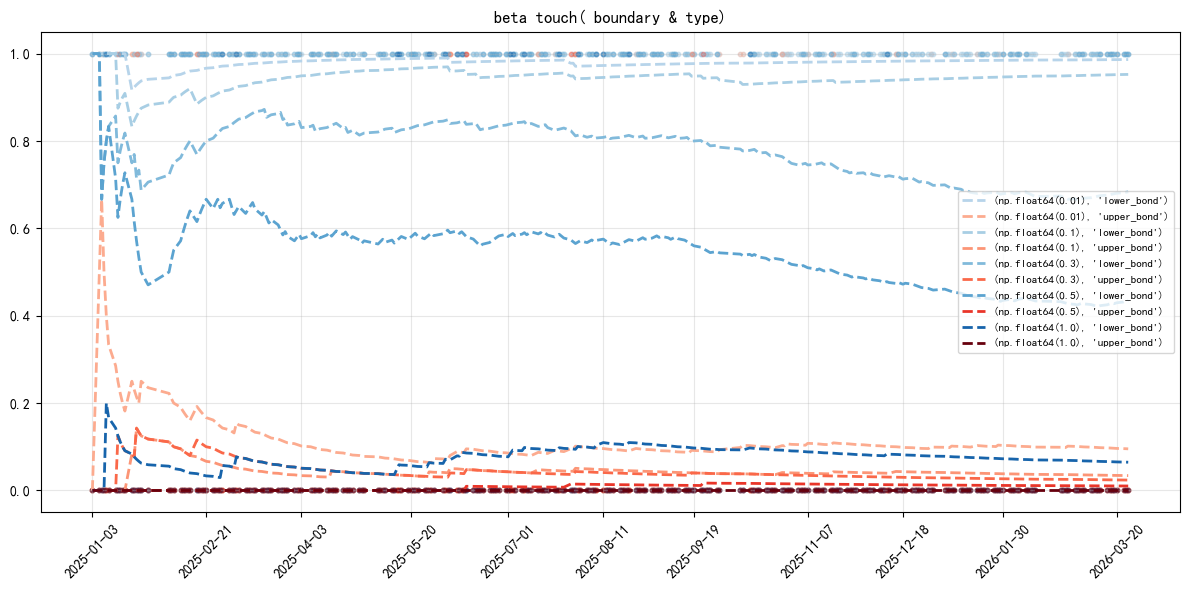

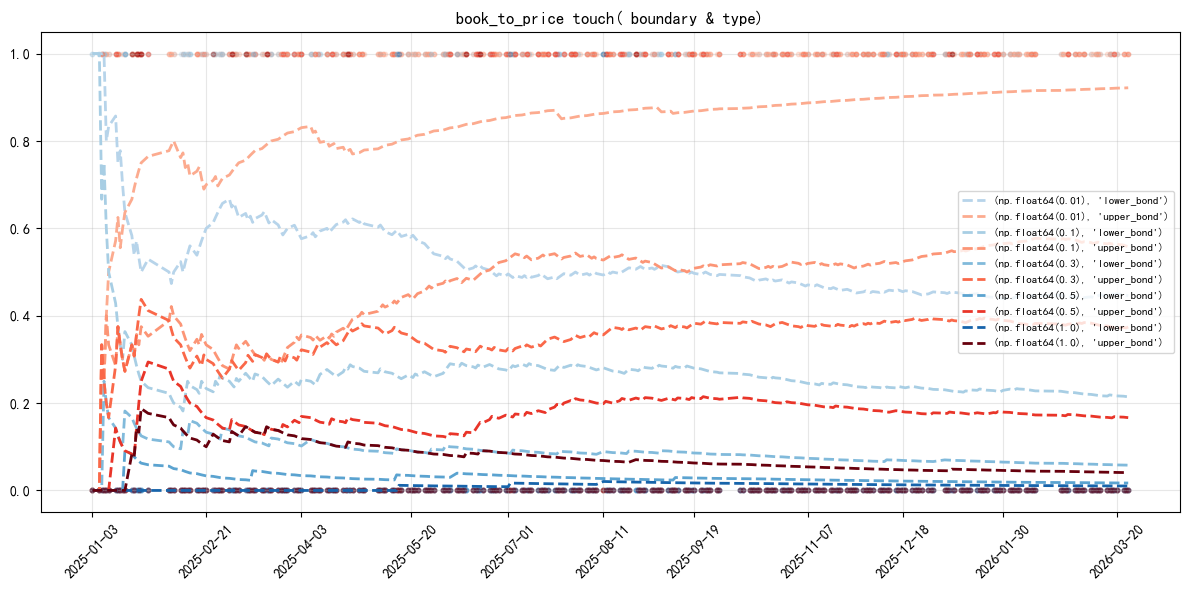

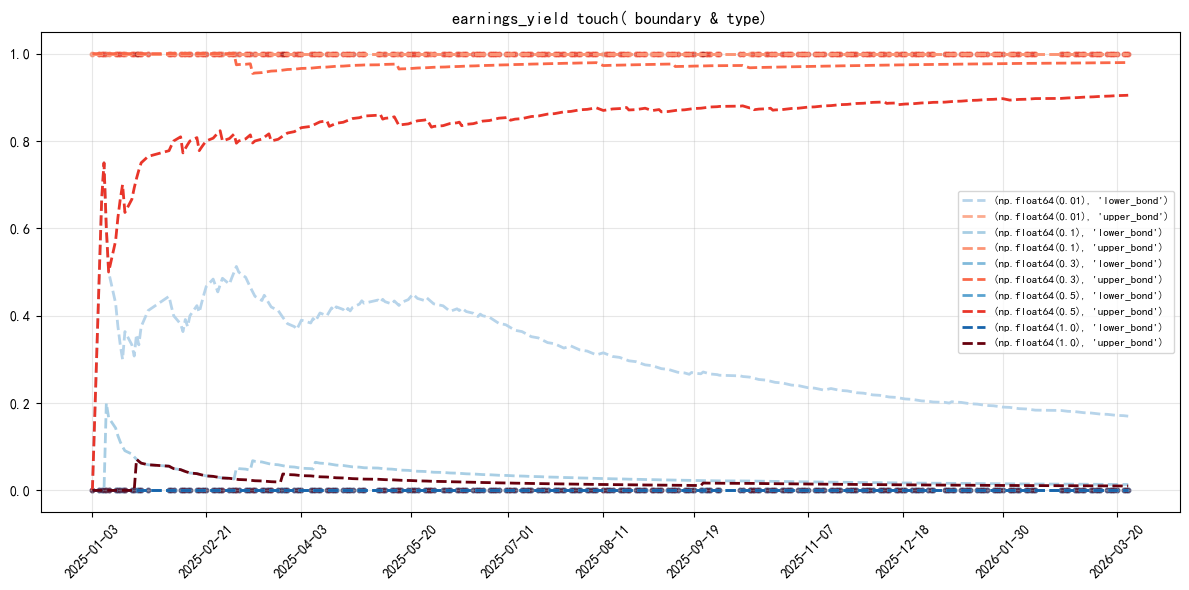

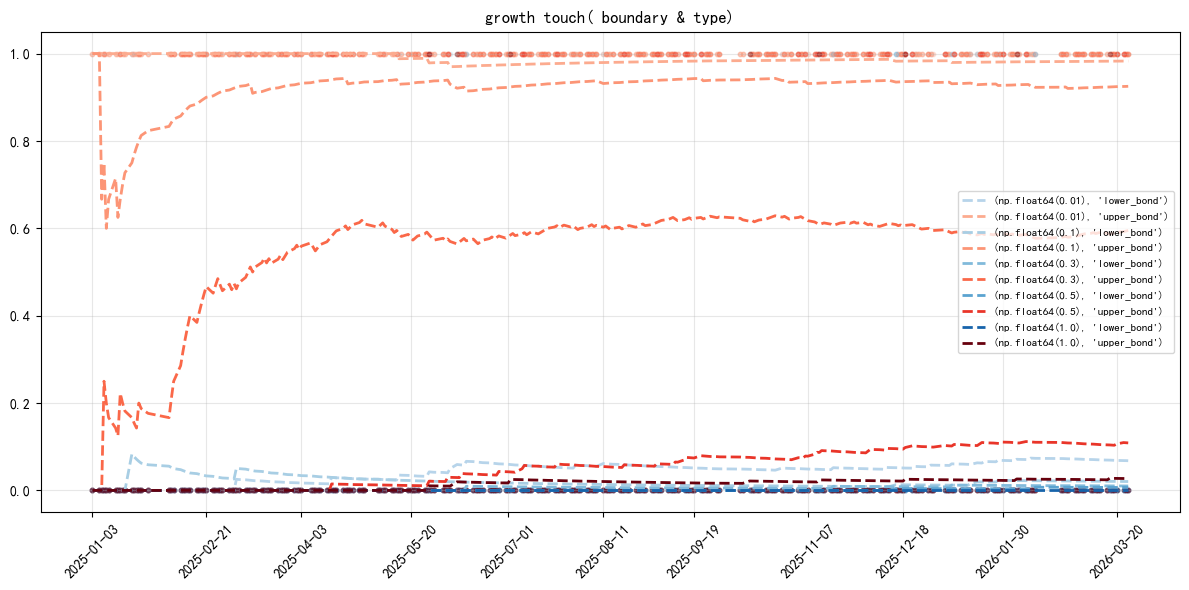

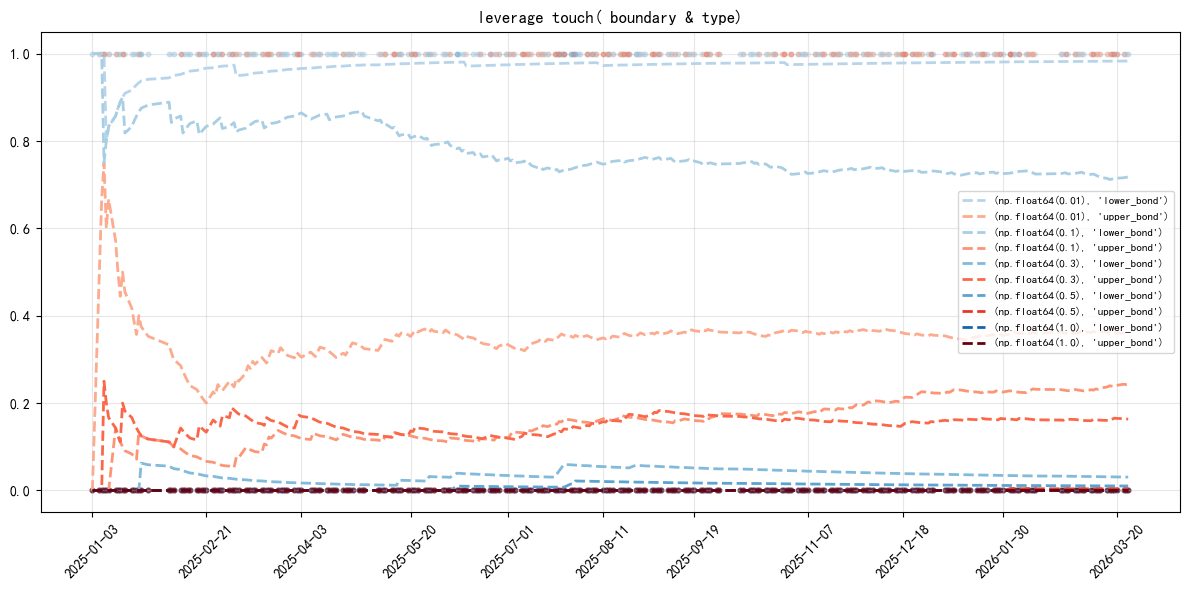

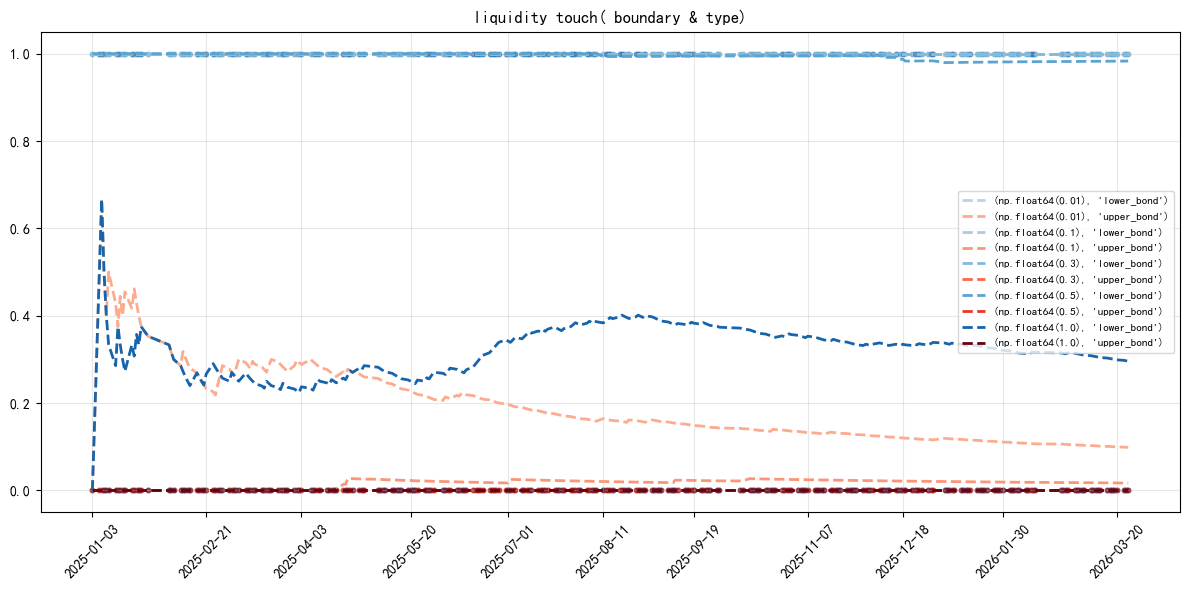

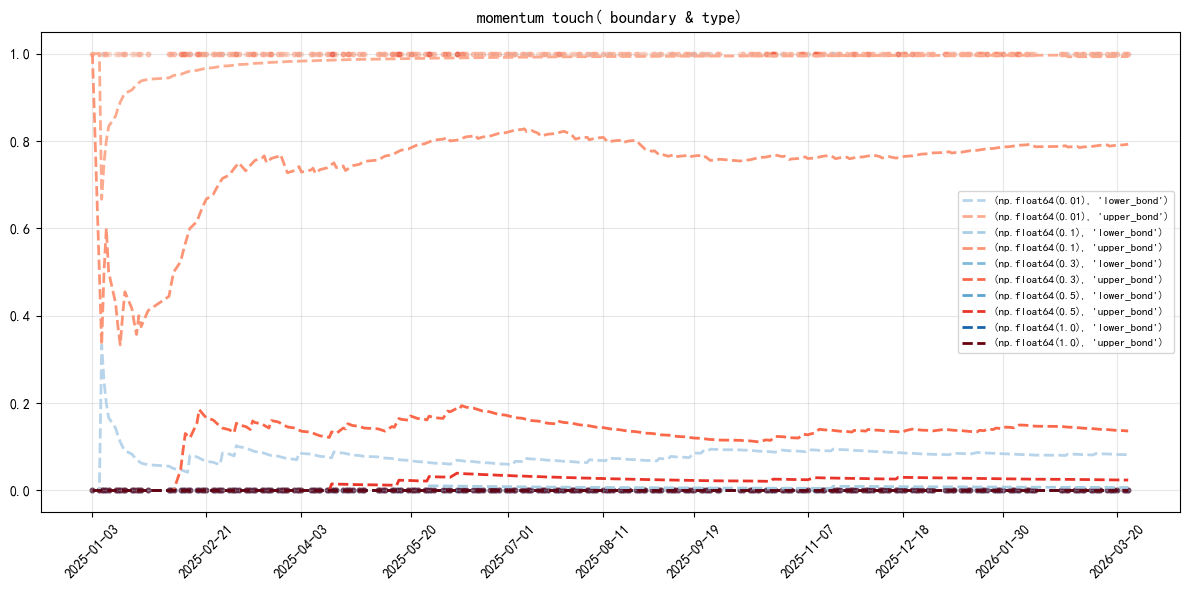

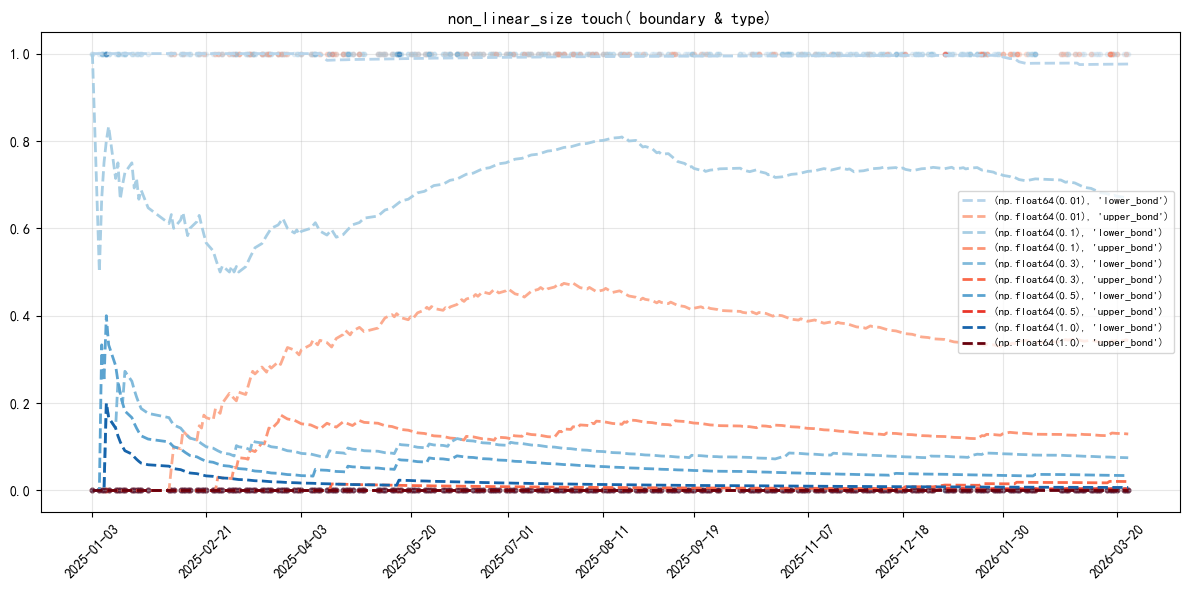

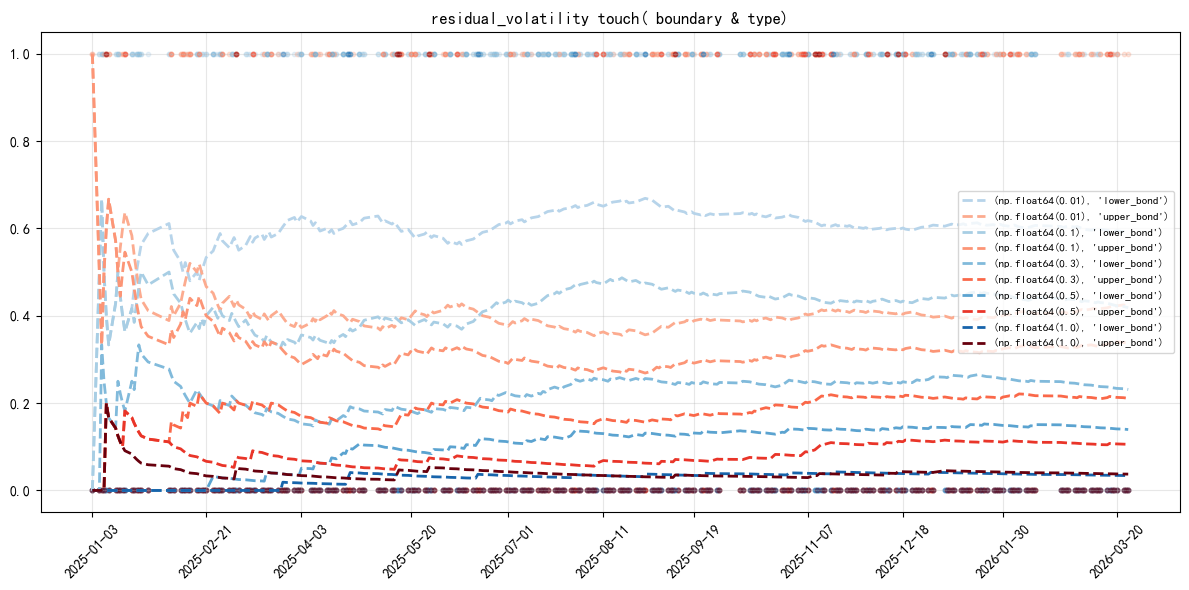

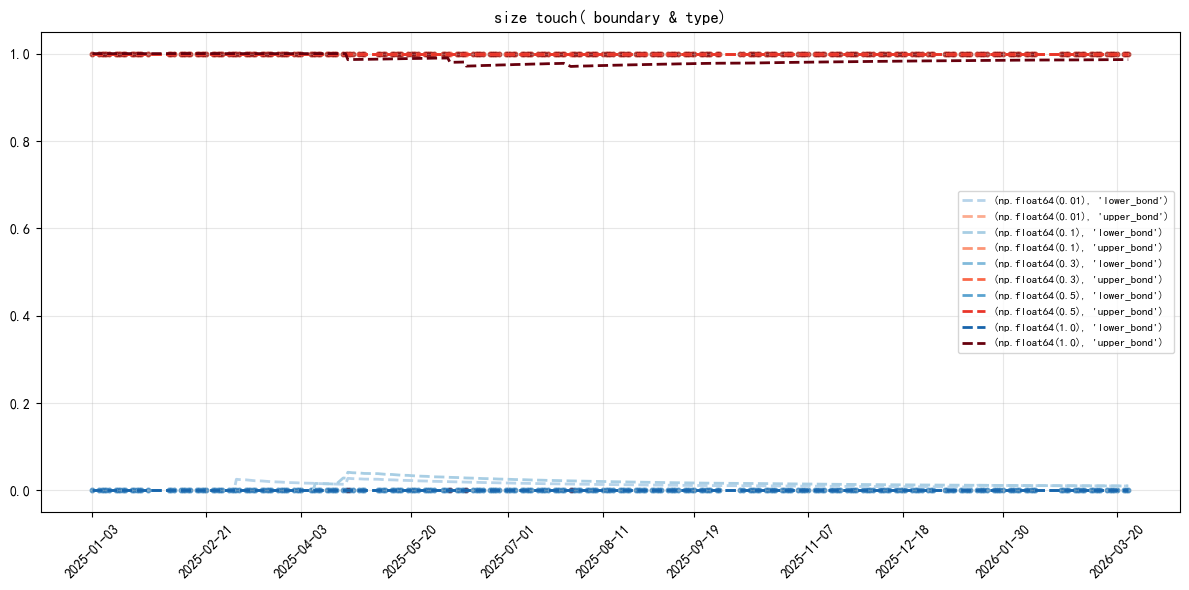

In [24]:
import matplotlib.pyplot as plt
import numpy as np
def parse_tag(tag):
    # tag = "(0.1, 'lower_bond')" 这种
    b, t = eval(tag)
    return float(b), t
def get_color(boundary, typ):
    # 归一化到 0~1
    norm = (boundary - b_min) / (b_max - b_min + 1e-8)
    if typ == 'lower_bond':
        return plt.cm.Blues(0.3 + 0.5 * norm)   # 浅蓝 → 稍深蓝
    else:
        return plt.cm.Reds(0.3 + 0.7 * norm)    # 浅红 → 深红
df = pd.DataFrame(res_dict,columns=["boundary","tradadate","type","factors"])
res = []

for _, row in df.iterrows():
    factors = row['factors']
    onehot = [1 if f in factors else 0 for f in orth_order]
    res.append(list(row) + onehot)

new_cols = list(df.columns) + orth_order
df_new = pd.DataFrame(res, columns=new_cols)
df_new["count"] = df_new[orth_order].sum(axis=1)
for fac in orth_order:
    temp = df_new[["boundary","tradadate","type"]+[fac]]
    res = []
    for g,df_s in temp.groupby(["boundary","type"]):
        tag = str(g)
        df_s.set_index("tradadate",inplace=True)
        df_s = df_s.rename({fac:tag},axis=1)
        res.append(df_s[[tag]])
    df_g = pd.concat(res,axis=1).fillna(0)
    #df_g.to_excel(f"{spedir}/组合优化/{fac}各约束强度的触线情况.xlsx")
    df_g.index= pd.to_datetime(df_g.index)
    # 提取 boundary 分布（用于归一化）
    boundaries = [parse_tag(c)[0] for c in df_g.columns]
    b_min, b_max = min(boundaries), max(boundaries)
    plt.figure(figsize=(12,6))
    # 1️⃣ 散点
    for col in df_g.columns:
        b, t = parse_tag(col)
        color = get_color(b, t)
        
        plt.scatter(df_g.index, df_g[col],
                    s=10, alpha=0.3, color=color)
    # 2️⃣ 趋势线（虚线）
    df_mean = df_g.expanding().mean()
    for col in df_mean.columns:
        b, t = parse_tag(col)
        color = get_color(b, t)
        
        plt.plot(df_mean.index, df_mean[col],
                linestyle='--', linewidth=2,
                color=color, label=col)
    # 美化
    step = max(1, len(df_g)//10)
    plt.xticks(df_g.index[::step], df_g.index[::step].strftime('%Y-%m-%d'), rotation=45)
    plt.title(f"{fac} touch( boundary & type)")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8,loc='center right')
    plt.tight_layout()
    plt.savefig(f"{spedir}/组合优化/{fac}各约束触线图.png")
    #plt.show()
#df["count"] = df.iloc[:,3:].notna().sum(axis=1)
# df.columns = ["boundary","tradadate","type"] + df.columns[3:].tolist()

# for t in ["upper_bond","lower_bond"]:
#     temp = df[df["type"]==t]
#     temp.to_excel(f"{spedir}/组合优化/各约束强度的触线详情{t}.xlsx")
#     df_lst = []
#     for g,df_sm in temp.groupby("boundary"):
#         tag = str(g)
#         df_sm.set_index("tradadate",inplace=True)
#         df_sm = df_sm.rename({"count":tag},axis=1)
#         df_lst.append(df_sm[[tag]])
#     df_g = pd.concat(df_lst,axis=1).fillna(0)
#     #df_g.to_excel(f"{spedir}/组合优化/各约束强度的触线情况{t}.xlsx")

,0.01,0.1,0.3,0.5,1.0,000905
2025-01-01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2025-01-03,0.995326,0.995093,0.995875,0.996943,0.998258,0.978700
2025-01-06,0.998269,0.998659,1.000030,1.000977,1.000680,0.978602
2025-01-07,1.001641,1.002841,1.003198,1.003211,1.002268,0.988975
2025-01-08,1.002087,1.004067,1.005525,1.005988,1.005857,0.984822
...,...,...,...,...,...,...
2026-03-19,0.962699,0.967624,0.981838,0.992212,1.006068,1.421401
2026-03-20,0.957843,0.963158,0.978393,0.989511,1.005138,1.400222
2026-03-23,0.948890,0.954766,0.971591,0.983966,1.002584,1.342673
2026-03-24,0.958130,0.963780,0.979501,0.990523,1.005906,1.370869


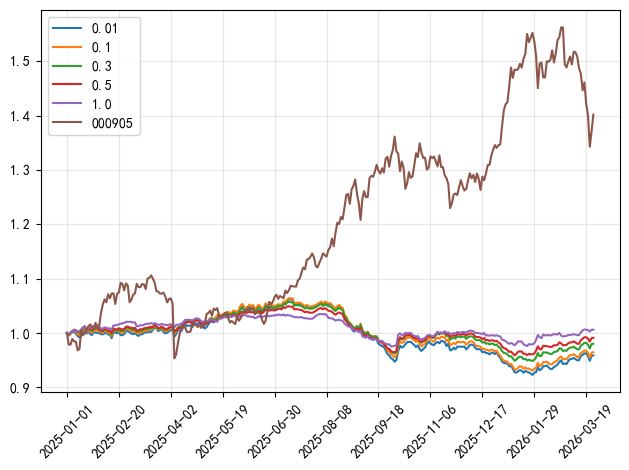

In [22]:
import matplotlib.pyplot as plt
import random

df_500 = pd.read_excel(f"{srcdir}/000905_SH.xlsx")
df_500.index = df_500["日期"].dt.strftime('%Y-%m-%d')
df_500.rename({"涨跌幅":"000905"},axis=1,inplace=True)

ret_df = pd.DataFrame(ret_dict,index=[f[:10] for f in files[1:]])
ret_df = ret_df.merge(df_500[["000905"]],left_index=True,right_index=True)
#ret_df = pd.DataFrame(ret_dict.items(),  # 键值对columns=["date", "value"]  # 列名你可以随便改).set_index("date")
temp = pd.DataFrame(0, index=["2025-01-01"], columns=ret_df.columns)
ret0_df = pd.concat([temp, ret_df], ignore_index=False)
ret_cum = (1 + ret0_df).cumprod()
# ret_cum.insert(0,0,0.9) #选
# ret_df.insert(0,0,0.9) #选

plt.plot(ret_cum,label=ret_cum.columns)
step = max(1, len(ret_cum) // 10)  # 最多显示10个刻度
plt.xticks(
    ticks=range(0, len(ret_cum), step),  # 按步长取刻度
    labels=ret_cum.index[::step],       # 对应标签
    rotation=45,                        # 标签倾斜45度（关键！）
    fontsize=10
)
plt.grid(alpha=0.3)  # 加网格更美观
plt.legend(loc='best')
plt.tight_layout()  # 自动适配布局，防止标签截断


# fig, ax1 = plt.subplots(figsize=(10, 6))
# ax1.plot(ret_cum.iloc[:, :-1], label=ret_cum.columns[:-1])
# ax1.legend(loc='best')
# ax1.grid(alpha=0.3)
# ax2 = ax1.twinx()
# ax2.plot(ret_cum.iloc[:, -1], color='red', label=ret_cum.columns[-1])
# ax2.legend(loc='upper right')
# # 统一X轴刻度（你原来的逻辑）
# step = max(1, len(ret_cum) // 10)
# ax1.set_xticks(range(0, len(ret_cum), step))
# ax1.set_xticklabels(ret_cum.index[::step], rotation=45, fontsize=10)
# plt.tight_layout()
# plt.show()
ret_cum

In [ ]:
#画净值曲线备用
import pandas as pd
import matplotlib.pyplot as plt
navdir =  "E:/SJTU/实习/国泰海通/barra因子/result/组合优化"
ret_cum = pd.read_excel(f"{navdir}/minmax_不同std_净值_完整因子部分正交【调方差】+ lam均衡.xlsx",index_col=0)
plt.plot(ret_cum,label=ret_cum.columns)
step = max(1, len(ret_cum) // 10)  # 最多显示10个刻度
plt.xticks(
    ticks=range(0, len(ret_cum), step),  # 按步长取刻度
    labels=ret_cum.index[::step],       # 对应标签
    rotation=45,                        # 标签倾斜45度（关键！）
    fontsize=10
)
plt.grid(alpha=0.3)  # 加网格更美观
plt.legend(loc='best')
plt.tight_layout()  # 自动适配布局，防止标签截断
ret_cum

In [23]:
#简单回测一下业绩
rf = 0.015
res = []
for i in range(1,ret_cum.shape[1]):
    port_nav = ret_cum.iloc[:,i]
    cum_ret = port_nav.iloc[-1] / port_nav.iloc[0] - 1
    ann_ret = (cum_ret + 1)**(252/len(port_nav)) - 1 #daily freq
    ann_vol = ret_df.iloc[:,i].std() * np.sqrt(252)
    sp = (ann_ret - rf) / ann_vol
    maxd = min(port_nav / port_nav.cummax()) - 1
    km = (ann_ret - rf) / abs(maxd) 
    result_dict = {
    '累计收益率': f'{float(cum_ret):.2%}',
    '年化收益率': f'{float(ann_ret):.2%}',
    '年化波动率': f'{float(ann_vol):.2%}',
    '夏普比率': f'{sp:.2f}',
    '最大回撤': f'{maxd:.2%}',
    '卡玛比率': f'{km:.2f}'}
    res.append(pd.Series(result_dict,name=ret_cum.columns[i]))

file_path = f"{spedir}/组合优化/minmax_不同std_净值.xlsx"
with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
    # 第一个表：ret_cum → Sheet1
    ret_cum.to_excel(writer, sheet_name='净值', index=True)
    
    # 第二个表：backtest → Sheet2（你要的）
    pd.concat(res,axis=1).to_excel(writer, sheet_name='回测结果', index=True, header=True)

print("Excel 保存成功！两个工作表都已写入 ✅")

Excel 保存成功！两个工作表都已写入 ✅


因子底层逻辑、与风险因子的相关性确认

In [ ]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")
srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/"
facdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/fac_ret/whole_mkt"
risk_factor = "momentum"
candidate_factor = 'MACD_HIST'
df_fac = pd.read_pickle(f"{facdir}/factor_returns_20_2603.pkl")
files = os.listdir(f"{srcdir}/alpha/macd")
ret_lst = {}

def calculate_macd_hist_factor_return(df, macd_col=candidate_factor, capital_col='capital', return_col='ret'):
    """
    计算MACD_HIST因子的收益率
    步骤：
    1. 将股票根据MACD_HIST分为大中小三组（30%、40%、30%）
    2. 每个组再根据capital分为大市值、小市值两组
    3. 计算六个组的市值加权收益率
    4. 因子收益率 = 大组平均 - 小组平均
    
    参数：
    df: 包含股票数据的DataFrame，必须包含MACD_HIST、capital和return列
    macd_col: MACD_HIST因子列名
    capital_col: 市值列名
    return_col: 收益率列名
    
    返回：
    factor_return: MACD_HIST因子的收益率
    """
    # 1. 根据MACD_HIST分组
    df['macd_group'] = pd.qcut(df[macd_col], q=[0, 0.3, 0.7, 1], labels=['small', 'medium', 'large'])
    
    # 2. 每个MACD组内根据capital分组
    grouped = df.groupby('macd_group')
    groups = []
    
    for name, group in grouped:
        # 每组内按capital分为大市值和小市值
        group['cap_group'] = pd.qcut(group[capital_col], q=2, labels=['small_cap', 'large_cap'])
        groups.append(group)
    
    df_with_groups = pd.concat(groups)
    
    # 3. 计算六个组的市值加权收益率
    # 计算每个组的总市值
    df_with_groups['weight'] = df_with_groups[capital_col] / df_with_groups.groupby(['macd_group', 'cap_group'])[capital_col].transform('sum')
    # 计算加权收益率
    df_with_groups['weighted_return'] = df_with_groups[return_col] * df_with_groups['weight']
    # 计算每个组的收益率
    group_returns = df_with_groups.groupby(['macd_group', 'cap_group'])['weighted_return'].sum()
    
    # 4. 计算因子收益率
    # 大组的大小市值平均
    large_avg = (group_returns.loc[('large', 'small_cap')] + group_returns.loc[('large', 'large_cap')]) / 2
    # 小组的大小市值平均
    small_avg = (group_returns.loc[('small', 'small_cap')] + group_returns.loc[('small', 'large_cap')]) / 2
    # 因子收益率
    factor_return = large_avg - small_avg
    
    return factor_return

for file in files:
    dt = file[:10]
    df_a = pd.read_pickle(f"{srcdir}/alpha/macd/{dt}.pkl")    
    df_b = pd.read_pickle(f"{srcdir}/base_data/whole_mkt/{dt}.pkl")
    df = pd.merge(df_a, df_b, left_on="order_book_id", right_on="code")
    alpha_ret = calculate_macd_hist_factor_return(df)
    ret_lst[dt] = alpha_ret
s_alpha = pd.Series(ret_lst.values(), index=pd.to_datetime(list(ret_lst.keys())),name='candidate')
print("candidate alpha's t-value:",s_alpha.mean() / s_alpha.std() * np.sqrt(len(s_alpha)))
df_comb = pd.merge(s_alpha,df_fac["momentum"],left_index=True,right_index=True)
df_comb.corr()

,candidate,momentum
candidate,1.000000,-0.350515
momentum,-0.350515,1.000000


16.835515001632